# **Unit 1 Assessment: Dataset 4 - Online Retail Transaction Analysis**

## Objectives

- Load and inspect the Online Retail transaction dataset.
- Assess data quality before making changes.
- Clean and transform the data using a documented ETL process.
- Create meaningful measures, including line revenue.
- Use exploratory analysis and visualisations to investigate customer, product, country, and time patterns.
- Identify growth opportunities and signals of underperformance across markets, products, customers, and time.
- Record findings, limitations, and questions for further investigation.

## Inputs

- `Data_Sets/Online_Retail.csv`
- The raw Online Retail transaction data supplied with this project.  From Kaggle.

## Outputs

- A validated cleaned dataset saved as `../outputs/cleaned_online_retail.csv`.
- Tables showing important summary measures.
- Static Matplotlib and Seaborn visualisations.
- Written findings, limitations, and possible next steps.

## Additional Comments

This notebook is designed to run from top to bottom because later cells depend on objects created earlier I reject the earlier multi notebook approach I had planned as it had to re-run all the code again, so was pointless.  I will use markdown formatting to clearly delineate the different Phases of my investigation and analysis.

The raw dataset will be preserved while cleaning decisions are tested and documented. Each visualisation will be linked to a question and a clearly defined metric.

The analysis is descriptive. It will identify patterns in the data but will not claim to prove causation, profitability, or customer identity.



# Phase 1 — setup and extraction

### Business intent — growth and performance

> This notebook is written for the Commercial Director of a UK-based online retailer. The client wants evidence to identify growth opportunities and signals of underperformance across markets, products, customers, and time periods.
>
> The analysis will not assume that the busiest market is the most valuable. It will compare transaction volume with revenue, average transaction value, customer activity, product range, and trends. One question is whether a market such as `Netherlands` could offer higher commercial value than transaction counts alone suggest.
>
> The overall hypothesis is documented in the supporting README notes. The notebook tests it through specific questions, metrics, tables, and visualisations. A future AI opportunity would be to prioritise markets or customer groups and flag unusual performance patterns; this descriptive notebook does not claim to build that AI system.

### Cell 1 — import the toolkit

> Import the libraries used throughout the notebook. Pandas works with table-shaped data; NumPy supports numerical work; Matplotlib and Seaborn create the visualisations. `pd`, `np`, `plt`, and `sns` are short names used later.

In [3]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")

# loads the tools I choose and sets a readable default style. It does not load or change the dataset.

### Cell 2 — locate and load the raw dataset

> Set the relative file path and read the CSV into `df_raw`. The `_raw` suffix means this is the untouched source table. Keep it unchanged so that every cleaning decision can be checked against the original.

In [18]:
# Load the supplied CSV into an untouched raw table so all later transformations remain reversible.
dataset_path = Path("../Data_Sets/Online_Retail.csv") # Store the relative path to the supplied CSV file in a variable.
df_raw = pd.read_csv(dataset_path) # Read the CSV into a pandas DataFrame we call df_raw, so we keep the raw data unchanged.

print("Loaded:", dataset_path)
print("Shape:", df_raw.shape)

Loaded: ../Data_Sets/Online_Retail.csv
Shape: (541909, 8)


### Cell 3 — first look before changing anything

> Establish what one row represents and what kinds of fields the raw table contains. These checks are reconnaissance, not cleaning.


In [6]:
display(df_raw.head())
print("Columns:", df_raw.columns.tolist())
print("\nData types:")
display(df_raw.dtypes)


,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850,United Kingdom


Columns: ['InvoiceNo', 'StockCode', 'Description', 'Quantity', 'InvoiceDate', 'UnitPrice', 'CustomerID', 'Country']

Data types:


InvoiceNo          str
StockCode          str
Description        str
Quantity         int64
InvoiceDate        str
UnitPrice      float64
CustomerID       int64
Country            str
dtype: object


___


# Phase 2 — ETL and data quality

## Phase 2A - investigation and decision stage

### Cell 4 — make a quality inventory

> Count missing values, exact duplicate rows, non-positive quantities, and non-positive prices before removing anything. The counts are evidence for later decisions.
> 

In [7]:
print("Missing values by column:")
display(df_raw.isna().sum())

print("Exact duplicate rows:", df_raw.duplicated().sum())
print("Rows with Quantity <= 0:", (df_raw["Quantity"] <= 0).sum())
print("Rows with UnitPrice <= 0:", (df_raw["UnitPrice"] <= 0).sum())

Missing values by column:


InvoiceNo         0
StockCode         0
Description    1454
Quantity          0
InvoiceDate       0
UnitPrice         0
CustomerID        0
Country           0
dtype: int64

Exact duplicate rows: 5268
Rows with Quantity <= 0: 10624
Rows with UnitPrice <= 0: 2517


Queries Raised:

The initial quality check shows four suspicious groups: missing descriptions 1,454, exact duplicate rows 5268, non-positive quantities 10624, and non-positive prices at 2517. These counts may overlap, so they should not be added together. The values are not automatically treated as errors; the next step is to investigate what each group represents before deciding how to handle it.


### Cell 5 — inspect cancellations and non-product stock codes

> Negative quantities may represent cancellations rather than ordinary sales. Stock codes containing letters may be postage, fees, or other non-product rows. I need to inspect these groups before deciding on how to handle this via a rule.


In [8]:
invoice_text = df_raw["InvoiceNo"].astype("string")
stock_text = df_raw["StockCode"].astype("string").str.strip()

print("Rows whose invoice number starts with C:", invoice_text.str.startswith("C").sum())
print("Negative-quantity rows with a C invoice:",
      ((df_raw["Quantity"] < 0) & invoice_text.str.startswith("C")).sum())

non_product_codes = df_raw.loc[~stock_text.str.match(r"^\d"), "StockCode"]
print("Most common non-numeric-leading stock codes:")
display(non_product_codes.value_counts().head(20))

Rows whose invoice number starts with C: 9288
Negative-quantity rows with a C invoice: 9288
Most common non-numeric-leading stock codes:


StockCode
POST            1256
DOT              710
M                571
C2               144
D                 77
S                 63
BANK CHARGES      37
AMAZONFEE         34
CRUK              16
DCGSSGIRL         13
DCGSSBOY          11
gift_0001_20      10
gift_0001_10       9
gift_0001_30       8
DCGS0003           5
gift_0001_50       4
PADS               4
gift_0001_40       3
B                  3
DCGS0076           2
Name: count, dtype: int64

<br>

### Analysis:

This tells me every C invoice row also has a negative quantity. In this dataset, the C prefix is therefore a strong indicator of cancellations or returns. However, something sticks out:

> - **Total negative-quantity rows:** 10,624
> - **Negative-quantity rows with no C prefix:** 1,336

Those 1,336 rows are the group I need to investigate next. They do not fit the obvious cancellation pattern.

The stock-code output also tells us that the table contains more than ordinary products. Codes such as:

POST
DOT
M
C2
BANK CHARGES
AMAZONFEE

These look like postage, charges, adjustments, or other operational records rather than merchandise. I am going to check their descriptions before deciding whether to remove them, and before moving on to transforming anything.




<br>

### Cell 5A — investigate negative quantities that are not C invoices - via CODEX

> I have posed my dataset problem to Codex, and asked for help in rooting out the reality from the mess. Cell 5 gives us the initial counts. The next question follows directly from those counts: among the negative-quantity rows, which ones have the `C` invoice prefix and which ones do not? Cell 5A investigates the non-`C` group before we decide how to treat it. The group cannot yet be labelled as cancellations. I will use it to follow up on the exception revealed by Cell 5. Separate the negative-quantity rows whose invoice number starts with `C` from the negative-quantity rows that do not. The second group cannot yet be labelled as cancellations.
>
>  The following code is Codex's solution. 

In [12]:
cancellation_mask = df_raw["InvoiceNo"].astype("string").str.startswith("C", na=False)
negative_quantity_mask = df_raw["Quantity"] < 0
other_negative_mask = negative_quantity_mask & ~cancellation_mask
other_negative_rows = df_raw.loc[other_negative_mask].copy()

print("Negative-quantity rows with a C invoice:",
      (negative_quantity_mask & cancellation_mask).sum())
print("Negative-quantity rows without a C invoice:",
      other_negative_mask.sum())
print("Missing descriptions in the non-C negative group:",
      other_negative_rows["Description"].isna().sum())
print("Present descriptions in the non-C negative group:",
      other_negative_rows["Description"].notna().sum())
print("Unit prices in the non-C negative group:")
display(other_negative_rows["UnitPrice"].value_counts(dropna=False).rename_axis("UnitPrice").to_frame("Rows"))

print("Description values present in the non-C negative group:")
description_counts = (
    other_negative_rows["Description"]
    .value_counts(dropna=False)
    .rename_axis("Description")
    .to_frame("Rows")
)
display(description_counts)

print("Rows with descriptions present:")
display(other_negative_rows.loc[
    other_negative_rows["Description"].notna(),
    ["InvoiceNo", "StockCode", "Description", "Quantity", "UnitPrice", "Country"]
].sort_values("Description"))

Negative-quantity rows with a C invoice: 9288
Negative-quantity rows without a C invoice: 1336
Missing descriptions in the non-C negative group: 862
Present descriptions in the non-C negative group: 474
Unit prices in the non-C negative group:


,Rows
UnitPrice,
0.0,1336


Description values present in the non-C negative group:


,Rows
Description,
NaN,862
check,120
damages,45
damaged,42
?,41
...,...
???,1
wet,1
wet boxes,1


Rows with descriptions present:


,InvoiceNo,StockCode,Description,Quantity,UnitPrice,Country
420391,572891,23343,20713,-400,0.0,United Kingdom
415583,572548,23343,20713 wrongly marked,-200,0.0,United Kingdom
7313,537032,21275,?,-30,0.0,United Kingdom
21518,538090,20956,?,-723,0.0,United Kingdom
43662,540100,22837,?,-106,0.0,United Kingdom
...,...,...,...,...,...,...
380688,569831,20713,wrongly coded-23343,-800,0.0,United Kingdom
456831,575722,85123A,wrongly marked carton 22804,-256,0.0,United Kingdom
263884,560039,20713,wrongly marked. 23343 in box,-3100,0.0,United Kingdom
114522,546018,85172,wrongly sold as sets,-600,0.0,United Kingdom


This is all about me seeing clearly so I can understand what I'm looking at.  All these negative quantity transactions are from the UK, have their own invoice number not a 'C', and most have no description. Now with Codex's help I can see that there are in fact some descriptions and they provide useful context. They include damage, wet packaging, incorrect markings, incorrect coding, and products sold as sets. This suggests that the group contains returns-related or stock-adjustment records rather than ordinary sales.

The `C` prefix therefore identifies one category of cancellation, but it does not identify every negative-quantity adjustment. This group should be retained separately while its treatment in the sales analysis is decided.

**What this doesn't prove:** the exact business process behind every row or whether each record represents a customer return.

### Cell 5B — investigate non-product stock codes

> After Cell 5A, I'll use the visible descriptions, prices, and rows to record what that exception group appears to contain. Cell 5B now follows the other question raised by Cell 5: do the non-numeric-leading stock codes represent ordinary products, or a separate set of operational or adjustment records? The code pattern identifies a group for investigation; it does not prove that every row should be removed.

In [13]:
stock_text = df_raw["StockCode"].astype("string").str.strip()
non_product_mask = ~stock_text.str.match(r"^\d", na=False)

non_product_summary = (
    df_raw.loc[non_product_mask]
      .groupby(["StockCode", "Description"], dropna=False)
      .agg(Rows=("StockCode", "size"),
           TotalQuantity=("Quantity", "sum"),
           LowestUnitPrice=("UnitPrice", "min"),
           HighestUnitPrice=("UnitPrice", "max"))
      .sort_values("Rows", ascending=False)
)

display(non_product_summary.head(20))

,,Rows,TotalQuantity,LowestUnitPrice,HighestUnitPrice
StockCode,Description,,,,
POST,POSTAGE,1252,3003,0.550,8142.750
DOT,DOTCOM POSTAGE,709,707,0.000,4505.170
M,Manual,571,3164,0.000,38970.000
C2,CARRIAGE,143,140,15.000,150.000
D,Discount,77,-1194,0.010,1867.860
S,SAMPLES,63,-59,2.800,570.000
BANK CHARGES,Bank Charges,37,-13,0.001,1050.150
AMAZONFEE,AMAZON FEE,34,-30,1.000,17836.460
CRUK,CRUK Commission,16,-16,1.600,1100.440


<br>

**Analysis:**

Cell 5B shows that the non-numeric stock-code population is mixed. The visible groups include postage, carriage, fees, discounts, samples, vouchers, and descriptions that appear product-related. Some groups also contain missing descriptions, zero prices, negative prices, or wide price ranges.

Because this output shows only the 20 largest groups, it is not enough to make a final cleaning decision. Cell 5B1 will audit the complete set of non-numeric stock-code groups so that each category can be treated according to visible evidence rather than an incomplete summary.

### Cell 5B1 — audit the complete non-numeric stock-code population

> Cell 5B showed a mixed set of non-numeric stock codes, but only the 20 largest groups were visible. This cell expands the check to every non-numeric stock-code and description group, displaying counts, quantities, price ranges, zero- and negative-price counts, negative-quantity counts, missing descriptions, and relevant rows for follow-up. These results will support the category-by-category ETL decisions.
>
> Most of this code was suggested by Codex.

In [14]:
# Keep stock codes that do not begin with a digit.
stock_text = df_raw["StockCode"].astype("string").str.strip()
non_product_mask = ~stock_text.str.match(r"^\d", na=False)

non_product_rows = df_raw.loc[non_product_mask].copy()

# Create flags so each issue can be counted by stock-code group.
non_product_rows["ZeroPrice"] = non_product_rows["UnitPrice"] == 0
non_product_rows["NegativePrice"] = non_product_rows["UnitPrice"] < 0
non_product_rows["NegativeQuantity"] = non_product_rows["Quantity"] < 0
non_product_rows["MissingDescription"] = non_product_rows["Description"].isna()

# Summarise every non-numeric stock-code and description group.
non_product_summary = (
    non_product_rows
    .groupby(["StockCode", "Description"], dropna=False)
    .agg(
        Rows=("StockCode", "size"),
        TotalQuantity=("Quantity", "sum"),
        LowestUnitPrice=("UnitPrice", "min"),
        HighestUnitPrice=("UnitPrice", "max"),
        ZeroPriceRows=("ZeroPrice", "sum"),
        NegativePriceRows=("NegativePrice", "sum"),
        NegativeQuantityRows=("NegativeQuantity", "sum"),
        MissingDescriptionRows=("MissingDescription", "sum"),
    )
    .sort_values("Rows", ascending=False)
)

display(non_product_summary.reset_index())

# Display rows needing direct description or price follow-up.
follow_up_mask = (
    non_product_rows["MissingDescription"]
    | (non_product_rows["UnitPrice"] <= 0)
)

print("Rows with a missing description or non-positive price:",
      follow_up_mask.sum())

display(non_product_rows.loc[
    follow_up_mask,
    ["InvoiceNo", "StockCode", "Description",
     "Quantity", "UnitPrice", "Country"]
].sort_values(["StockCode", "Description"], na_position="first"))

,StockCode,Description,Rows,TotalQuantity,LowestUnitPrice,HighestUnitPrice,ZeroPriceRows,NegativePriceRows,NegativeQuantityRows,MissingDescriptionRows
0,POST,POSTAGE,1252,3003,0.550,8142.750,0,0,126,0
1,DOT,DOTCOM POSTAGE,709,707,0.000,4505.170,2,0,1,0
2,M,Manual,571,3164,0.000,38970.000,6,0,244,0
3,C2,CARRIAGE,143,140,15.000,150.000,0,0,2,0
4,D,Discount,77,-1194,0.010,1867.860,0,0,77,0
5,S,SAMPLES,63,-59,2.800,570.000,0,0,61,0
6,BANK CHARGES,Bank Charges,37,-13,0.001,1050.150,0,0,25,0
7,AMAZONFEE,AMAZON FEE,34,-30,1.000,17836.460,0,0,32,0
8,CRUK,CRUK Commission,16,-16,1.600,1100.440,0,0,16,0
9,DCGSSGIRL,GIRLS PARTY BAG,13,47,1.250,3.290,0,0,0,0


Rows with a missing description or non-positive price: 32


,InvoiceNo,StockCode,Description,Quantity,UnitPrice,Country
299983,A563186,B,Adjust bad debt,1,-11062.06,United Kingdom
299984,A563187,B,Adjust bad debt,1,-11062.06,United Kingdom
453999,575506,C2,NaN,150,0.00,United Kingdom
279258,561256,DCGS0003,ebay,-7,0.00,United Kingdom
74825,542529,DCGS0055,NaN,-1,0.00,United Kingdom
75295,542582,DCGS0057,NaN,-6,0.00,United Kingdom
279257,561255,DCGS0066P,NaN,-3,0.00,United Kingdom
279256,561254,DCGS0067,ebay,-11,0.00,United Kingdom
279255,561253,DCGS0068,ebay,-10,0.00,United Kingdom
279254,561252,DCGS0069,ebay,-5,0.00,United Kingdom


<br>

**Analysis:**

Cell 5B1 shows us that the non-numeric stock-code population is mixed. Postage groups dominate the flagged rows by count, but this summary does not show their effect on revenue or product trends - which is my area of interest here. Other groups have product-like descriptions or different price and quantity patterns, so a blanket removal rule would be unsafe. So I will need one more step - Cell 5B2 will measure the analytical impact of these groups before I make my ETL decisions regarding this dataset - and these decisions will be shaped by what I want to do with the data.

<br>

### Cell 5B2 — measure the analytical impact of the identified groups

> Cell 5B1 summarised and flagged the non-numeric stock-code groups, but counts alone do not show whether they materially affect the measures I plan to analyse. This cell compares the groups using row counts, total quantity, provisional line revenue (`Quantity × UnitPrice`), and their shares of the overall table. This provides impact evidence for the category-by-category ETL decisions.  I may be being over cautious here - but this is my first time so be gentle with me.


In [15]:
# Calculate provisional line revenue without changing the raw table.
impact_rows = non_product_rows.copy()
impact_rows["LineRevenue"] = impact_rows["Quantity"] * impact_rows["UnitPrice"]

total_rows = len(df_raw)
total_line_revenue = (df_raw["Quantity"] * df_raw["UnitPrice"]).sum()

impact_summary = (
    impact_rows
    .groupby(["StockCode", "Description"], dropna=False)
    .agg(
        Rows=("StockCode", "size"),
        TotalQuantity=("Quantity", "sum"),
        TotalRevenue=("LineRevenue", "sum"),
    )
    .assign(
        ShareOfRows=lambda table: table["Rows"] / total_rows * 100,
        ShareOfRevenue=lambda table: table["TotalRevenue"] / total_line_revenue * 100,
    )
    .sort_values("TotalRevenue", ascending=False)
)

print("Non-numeric stock-code rows:", len(non_product_rows))
print(f"Share of all rows: {len(non_product_rows) / total_rows * 100:.2f}%")
print("Non-numeric stock-code line revenue:",
      f"£{impact_rows['LineRevenue'].sum():,.2f}")
print(f"Share of all line revenue: {impact_rows['LineRevenue'].sum() / total_line_revenue * 100:.2f}%")

display(impact_summary.reset_index())

Non-numeric stock-code rows: 2995
Share of all rows: 0.55%
Non-numeric stock-code line revenue: £-44,562.50
Share of all line revenue: -0.46%


,StockCode,Description,Rows,TotalQuantity,TotalRevenue,ShareOfRows,ShareOfRevenue
0,DOT,DOTCOM POSTAGE,709,707,206245.480,0.130834,2.115827e+00
1,POST,POSTAGE,1252,3003,66230.640,0.231035,6.794456e-01
2,C2,CARRIAGE,143,140,6986.000,0.026388,7.166784e-02
3,gift_0001_30,Dotcomgiftshop Gift Voucher £30.00,7,7,175.530,0.001292,1.800724e-03
4,gift_0001_50,Dotcomgiftshop Gift Voucher £50.00,4,4,167.560,0.000738,1.718961e-03
5,gift_0001_20,Dotcomgiftshop Gift Voucher £20.00,9,10,167.050,0.001661,1.713729e-03
6,DCGSSBOY,BOYS PARTY BAG,11,47,150.550,0.002030,1.544459e-03
7,DCGSSGIRL,GIRLS PARTY BAG,13,47,144.430,0.002399,1.481676e-03
8,gift_0001_40,Dotcomgiftshop Gift Voucher £40.00,3,3,100.700,0.000554,1.033059e-03
9,gift_0001_10,Dotcomgiftshop Gift Voucher £10.00,8,9,74.970,0.001476,7.691007e-04


<br>

### Analysis:

Mmm?  Non-numeric stock-code rows are a small proportion of the dataset by row count, but their revenue effect is not uniform. The overall net impact is -0.46% of total provisional line revenue, but individual groups can have much larger positive or negative effects. The population therefore should not be removed as one blanket category. The raw rows should be retained, with operational, financial, voucher, and product-like groups considered separately according to the analysis question.

### Cell 5B2 — evidence-led conclusion

> The 2,995 non-numeric stock-code rows represent 0.55% of the dataset. Their combined provisional line revenue is £-44,562.50, or -0.46% of total provisional line revenue. However, individual groups have very different effects: some postage-related groups contribute positive revenue, while fees and manual adjustments contribute negative revenue. So I will not remove all non-numeric stock-code rows as one category. I will retain the raw rows and assess operational, financial, voucher, and product-like groups separately according to the analysis question. Before recording the final ETL decisions I need to check whether zero or negative prices and missing descriptions occur within these groups or elsewhere in the dataset.


<br>

### Cell 5C — investigate non-positive prices and missing descriptions

> Cells 5B1 and 5B2 show the complete groups and their provisional analytical impact. The next question is whether zero or negative prices, and missing descriptions, occur in these or other rows. Cell 5C separates those conditions so they are not collapsed into one automatic cleaning rule.

In [16]:
zero_price_mask = df_raw["UnitPrice"] == 0
negative_price_mask = df_raw["UnitPrice"] < 0
missing_description_mask = df_raw["Description"].isna()

print("Rows with UnitPrice == 0:", zero_price_mask.sum())
print("Rows with UnitPrice < 0:", negative_price_mask.sum())
print("Rows with missing Description:", missing_description_mask.sum())

suspicious_rows = df_raw.loc[
    zero_price_mask | negative_price_mask | missing_description_mask,
    ["InvoiceNo", "StockCode", "Description", "Quantity", "UnitPrice"]
].sort_values(["StockCode", "Description"], na_position="first")

print("Rows requiring direct inspection:", len(suspicious_rows))
display(suspicious_rows)

Rows with UnitPrice == 0: 2515
Rows with UnitPrice < 0: 2
Rows with missing Description: 1454
Rows requiring direct inspection: 2517


,InvoiceNo,StockCode,Description,Quantity,UnitPrice
139083,548286,10002,NaN,180,0.0
171573,551429,10002,NaN,-3,0.0
279310,561271,10080,NaN,170,0.0
454350,575518,10080,check,22,0.0
265293,560213,10123C,NaN,-18,0.0
...,...,...,...,...,...
326552,565556,POST,NaN,750,0.0
453998,575505,POST,NaN,800,0.0
317501,564762,gift_0001_10,NaN,30,0.0
228807,556955,gift_0001_20,to push order througha s stock was,10,0.0


<br>

### Cell 5C — evidence-led conclusion

> ### Cell 5C — evidence-led conclusion

> I am happier now. Cell 5C identifies 2,515 rows with a zero UnitPrice, 2 rows with a negative UnitPrice, and 1,454 rows with missing descriptions. Cell 10 reports 2,517 rows with a non-positive UnitPrice, and Cell 5C also identifies 2,517 rows requiring inspection. Taken together, this shows that the missing-description rows fall within the non-positive-price population rather than forming an additional positive-price group.
>
> For the primary paid-sales analysis, zero-price rows and negative-price adjustment rows will therefore be excluded from the working analysis table. Missing descriptions will not be imputed for this purpose. These rows will remain in the unchanged raw dataset for audit and any separate investigation, but they will not be treated as paid product sales. This completes the evidence needed for my ETL decision checkpoint.

<br>

### Cell 5D — visualise the pre-ETL quality baseline

> Cells 4–5C identified several quality conditions before any transformation was applied. This chart provides a visual baseline for the number of rows affected by each condition. These are separate checks and may overlap, so the bars must not be added together. Cell 9 will provide the corresponding after-ETL validation.

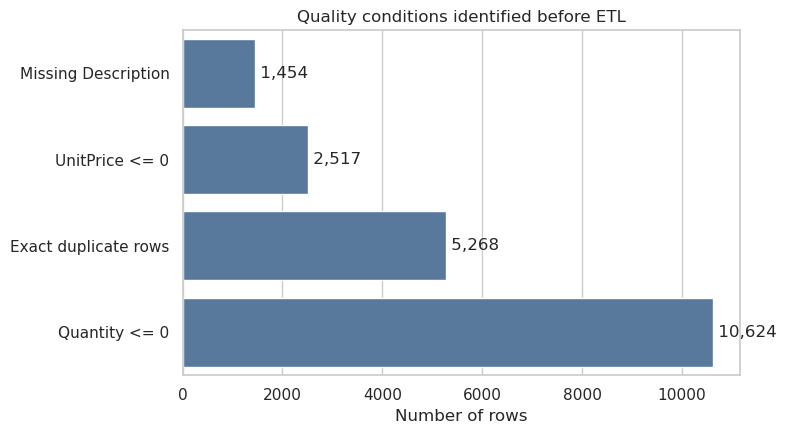

In [19]:
# Recalculate the baseline checks from the untouched raw table.
quality_counts = pd.Series({
    "Exact duplicate rows": df_raw.duplicated().sum(),
    "Quantity <= 0": (df_raw["Quantity"] <= 0).sum(),
    "UnitPrice <= 0": (df_raw["UnitPrice"] <= 0).sum(),
    "Missing Description": df_raw["Description"].isna().sum(),
}).sort_values()

# Use horizontal bars so the category labels remain easy to read.
fig, ax = plt.subplots(figsize=(8, 4.5))

sns.barplot(
    x=quality_counts.values,
    y=quality_counts.index,
    color="#4C78A8",
    ax=ax
)

ax.set_title("Quality conditions identified before ETL")
ax.set_xlabel("Number of rows")
ax.set_ylabel("")

# Add exact values because the chart is showing scale, not replacing the counts.
for position, value in enumerate(quality_counts.values):
    ax.text(value, position, f" {value:,}", va="center")

plt.tight_layout()
plt.show()

### Decision checkpoint — investigation and decisions - ETL decisions for the sales analysis

> The raw dataset will be retained unchanged as the audit source. The working analysis table will represent paid product sales rather than every transaction-like row.
>
> Exact duplicate rows will be excluded from the working analysis table to avoid double-counting identical records.
>
> C-invoice cancellations and the 1,336 negative-quantity rows without C invoices will be treated separately from gross product sales. Their evidence points to cancellations, damages, checks, or other adjustments rather than normal paid sales.
>
> Zero-price rows will be excluded from paid-sales metrics because they cannot contribute line revenue. The two negative-price rows will also be excluded because they represent financial adjustments rather than product sales.
>
> Operational and financial non-numeric stock-code groups—including postage, carriage, discounts, samples, bank charges, fees, commissions, bad debt, and manual adjustments—will be excluded from product-level analysis. Product-like non-numeric codes will be retained where they represent positive-price product lines.
>
> Missing descriptions will not be imputed for the core sales analysis. These rows occur within the non-positive-price population and will be retained separately for audit rather than treated as paid product sales.
>
> I make these scope decisions for analysing paid product, market, customer, and time patterns, which was my initial aim. They do not claim that the excluded rows are meaningless; but they do place them outside the primary sales-analysis table.

___

## Phase 2B - Applying the Decisions and Prepare the Analysis Table

### Cell 6 — create a working copy and standardise fields

> Finally I can now create the working copy and standardise text and date fields. This is a reversible transformation step; it does not remove rows or replace the decisions you have just documented.

In [17]:
df = df_raw.copy()

df["InvoiceDate"] = pd.to_datetime(df["InvoiceDate"])
df["InvoiceNo"] = df["InvoiceNo"].astype("string").str.strip()
df["StockCode"] = df["StockCode"].astype("string").str.strip()
df["Description"] = df["Description"].astype("string").str.strip()






NOTE

* You may add as many sections as you want, as long as it supports your project workflow.
* All notebook's cells should be run top-down (you can't create a dynamic wherein a given point you need to go back to a previous cell to execute some task, like go back to a previous cell and refresh a variable content)

---

# Push files to Repo

* In cases where you don't need to push files to Repo, you may replace this section with "Conclusions and Next Steps" and state your conclusions and next steps.

In [ ]:
import os
try:
  # create your folder here
  # os.makedirs(name='')
except Exception as e:
  print(e)


---